# Weather Typing

## Predictor - Load large scale atmospheric variables

### mean sea level pressure, spatial gradient of mean sea level pressure

In [2]:
import regionmask
import xarray as xr
from utils.data import load_atmospheric_predictor

# Define the variables and region
variables = ["msl", "msl_gradient"]
region = (17, 27, 40, 40)
estela = False

# Load the ERA5 dynamic predictors
# predictor = load_atmospheric_predictor(
#     variables=variables, region=region, estela=estela
# )
predictor = xr.open_dataset("inputs/daily_predictor_1979_2018.nc")
mask = regionmask.defined_regions.natural_earth_v5_0_0.land_110.mask(
    predictor.rename({"longitude": "lon", "latitude": "lat"})
)
predictor["mask"] = mask.rename({"lon": "longitude", "lat": "latitude"})
predictor = predictor.where(predictor.mask != 0)
predictor

<xarray.Dataset> Size: 39MB
Dimensions:       (time: 14610, latitude: 14, longitude: 24)
Coordinates:
  * latitude      (latitude) float32 56B 40.0 39.0 38.0 37.0 ... 29.0 28.0 27.0
  * longitude     (longitude) float32 96B 17.0 18.0 19.0 20.0 ... 38.0 39.0 40.0
  * time          (time) datetime64[ns] 117kB 1979-01-01 ... 2018-12-31
Data variables:
    msl           (time, latitude, longitude) float32 20MB 1e+05 1e+05 ... nan
    msl_gradient  (time, latitude, longitude) float32 20MB 7.955e+04 ... nan
    mask          (latitude, longitude) float64 3kB nan nan nan ... nan nan nan
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-02-13T19:10 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

## Predictor - Define weather types

### PCA + KMA

In [3]:
from bluemath_tk.datamining.kma import KMA
from bluemath_tk.datamining.pca import PCA
from bluemath_tk.predictor.xwt import XWT

pca = PCA(n_components=0.9)
kma = KMA(num_clusters=36, seed=42)

xwt = XWT(steps={"pca": pca, "kma": kma})
xwt.fit(
    data=predictor,
    fit_params={
        "pca": {
            "vars_to_stack": variables,
            "coords_to_stack": ["latitude", "longitude"],
            "pca_dim_for_rows": "time",
            "value_to_replace_nans": {"msl": 101325.0, "msl_gradient": 0.0},
        },
        "kma": {
            "normalize_data": False,
            "min_number_of_points": 25,
            "max_number_of_iterations": 100,
        },
    },
    variable_to_sort_bmus="msl",
)

# xwt._exclude_attributes = []  # To save data used for fitting
xwt.save_model("outputs/dwt_model_alexandria.pkl")

2025-10-14 12:53:03,629 - PCA - WARNING - Using 124 out of 336 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2025-10-14 12:53:03,638 - PCA - WARNING - Using 124 out of 336 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


2025-10-14 12:53:04,080 - PCA - WARNING - Attribute pcs is an xarray Dataset / Dataarray and will be pickled!


## Predictor - Describe Weather Types

### Plotting + Statistics

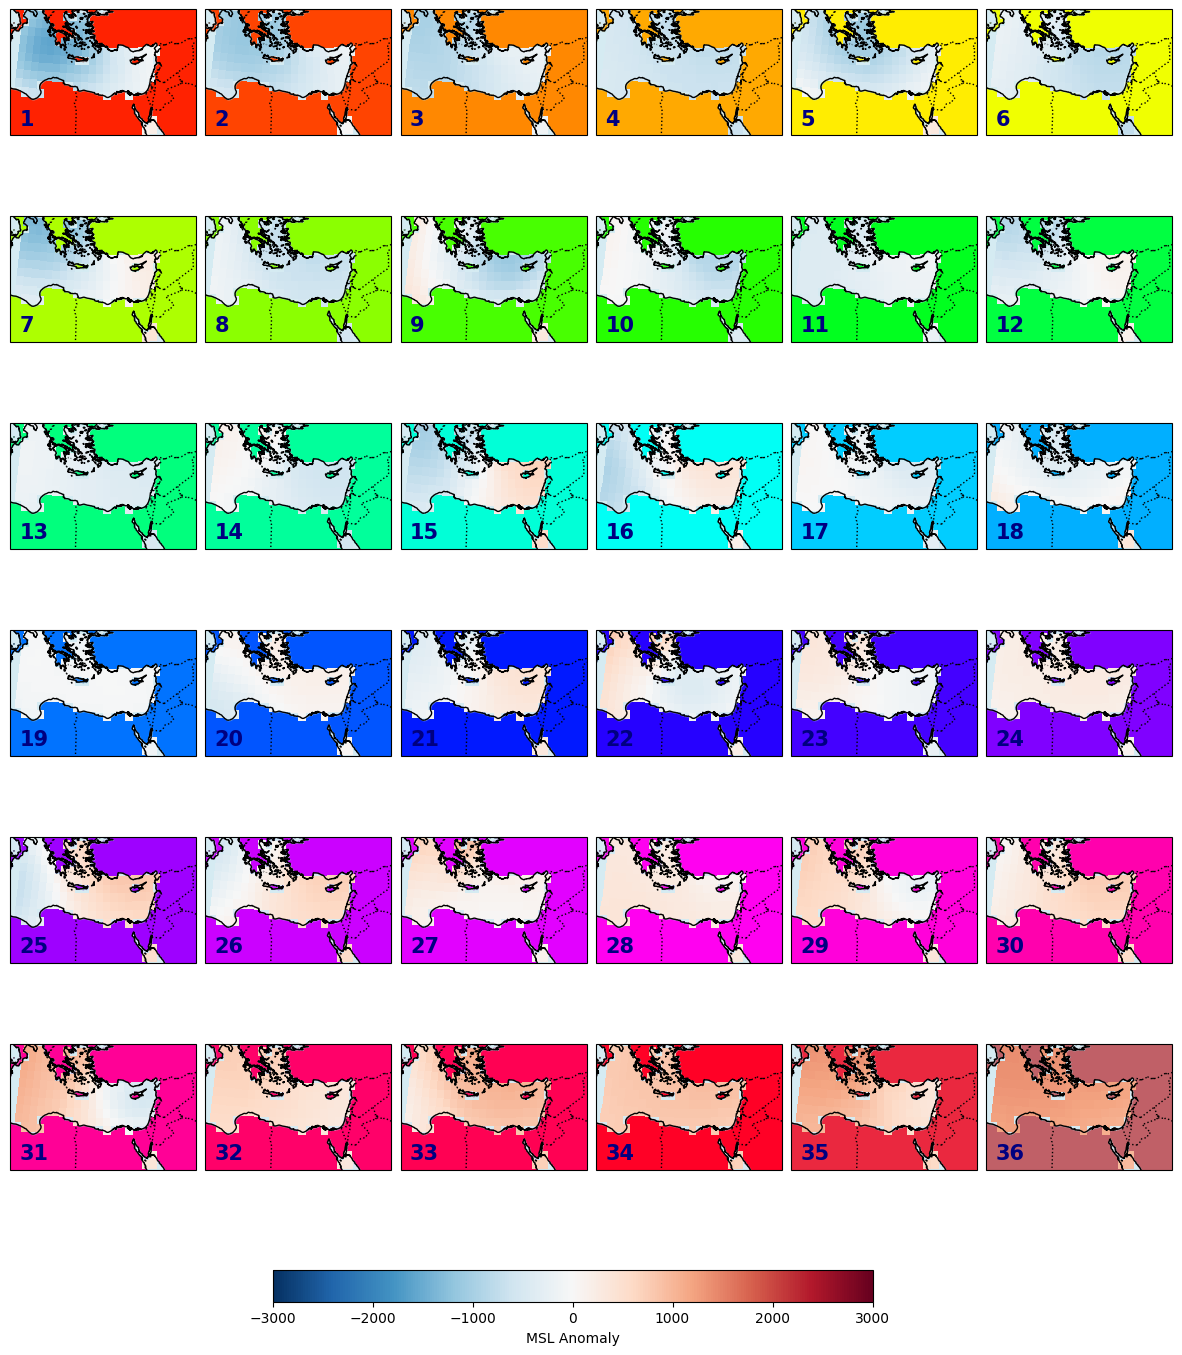

In [4]:
from bluemath_tk.predictor.xwt import config_variables

config_variables["msl"] = {
    "vmin": -3000,
    "vmax": 3000,
    "label": "MSL Anomaly",
}
xwt.plot_xwts(var_to_plot="msl", anomaly=True, map_center=(29, 29))

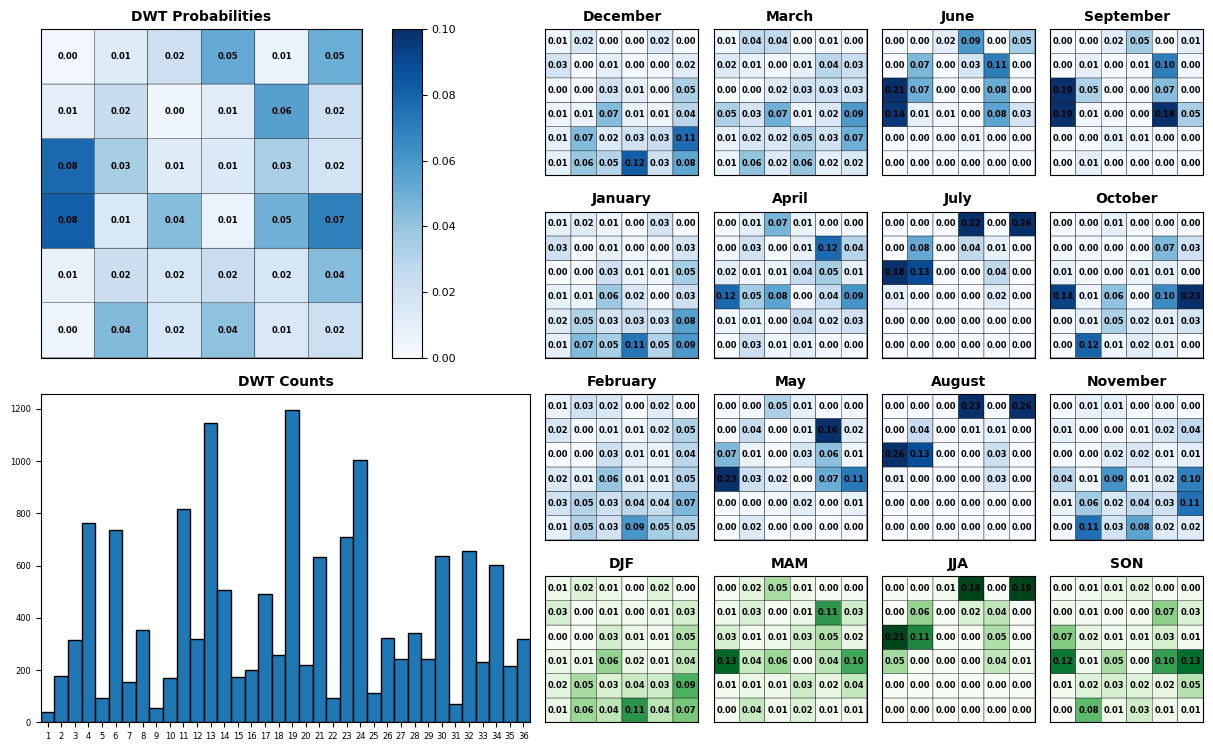

In [5]:
xwt.plot_dwts_probs(plot_text=True)

<Axes: >

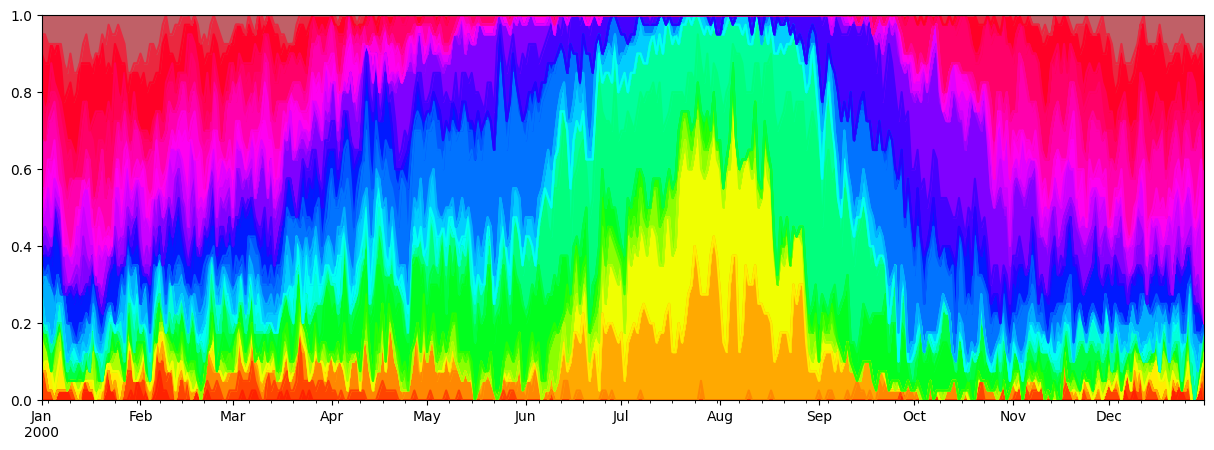

In [6]:
xwt.plot_perpetual_year()

## Predictand - Load regional/local wave data and SS data

### significant wave height, peak period, mean wave direction and SS

In [7]:
# import xarray as xr

# waves = (
#     xr.open_dataset("inputs/waves/ERA5_bulk_waves.nc")
#     .isel(latitude=0, longitude=0)
#     .resample(valid_time="1D")
#     .mean()
#     .sel(
#         valid_time=xwt.kma_bmus.loc["1979":"2018"].index.values,
#         method="nearest",
#         tolerance="1D",
#     )
# )

# ss = (
#     xr.open_dataset("inputs/sea_level/CODEC_alexandria_hourly.nc")
#     .resample(time="1D")
#     .max()
#     .sel(
#         time=xwt.kma_bmus.loc["1979":"2018"].index.values,
#         method="nearest",
#         tolerance="1D",
#     )
# )

# print(waves, ss)

In [8]:
import xarray as xr

predictand = xr.open_dataset("inputs/daily_predictand_1979_2018.nc")
predictand["kma_bmus"] = (("time"), xwt.kma_bmus.loc["1979":"2018"].kma_bmus.values)
predictand

<xarray.Dataset> Size: 643kB
Dimensions:   (time: 14610)
Coordinates:
  * time      (time) datetime64[ns] 117kB 1979-01-01 1979-01-02 ... 2018-12-31
Data variables:
    swh       (time) float64 117kB ...
    pp1d      (time) float64 117kB ...
    mwd       (time) float64 117kB ...
    ss        (time) float64 117kB ...
    kma_bmus  (time) int32 58kB 7 7 5 33 33 28 32 31 ... 34 28 29 31 32 32 32 26

## Predictand to Predictor - Model

### Empirical distribution of wave parameters conditioned to each weather type

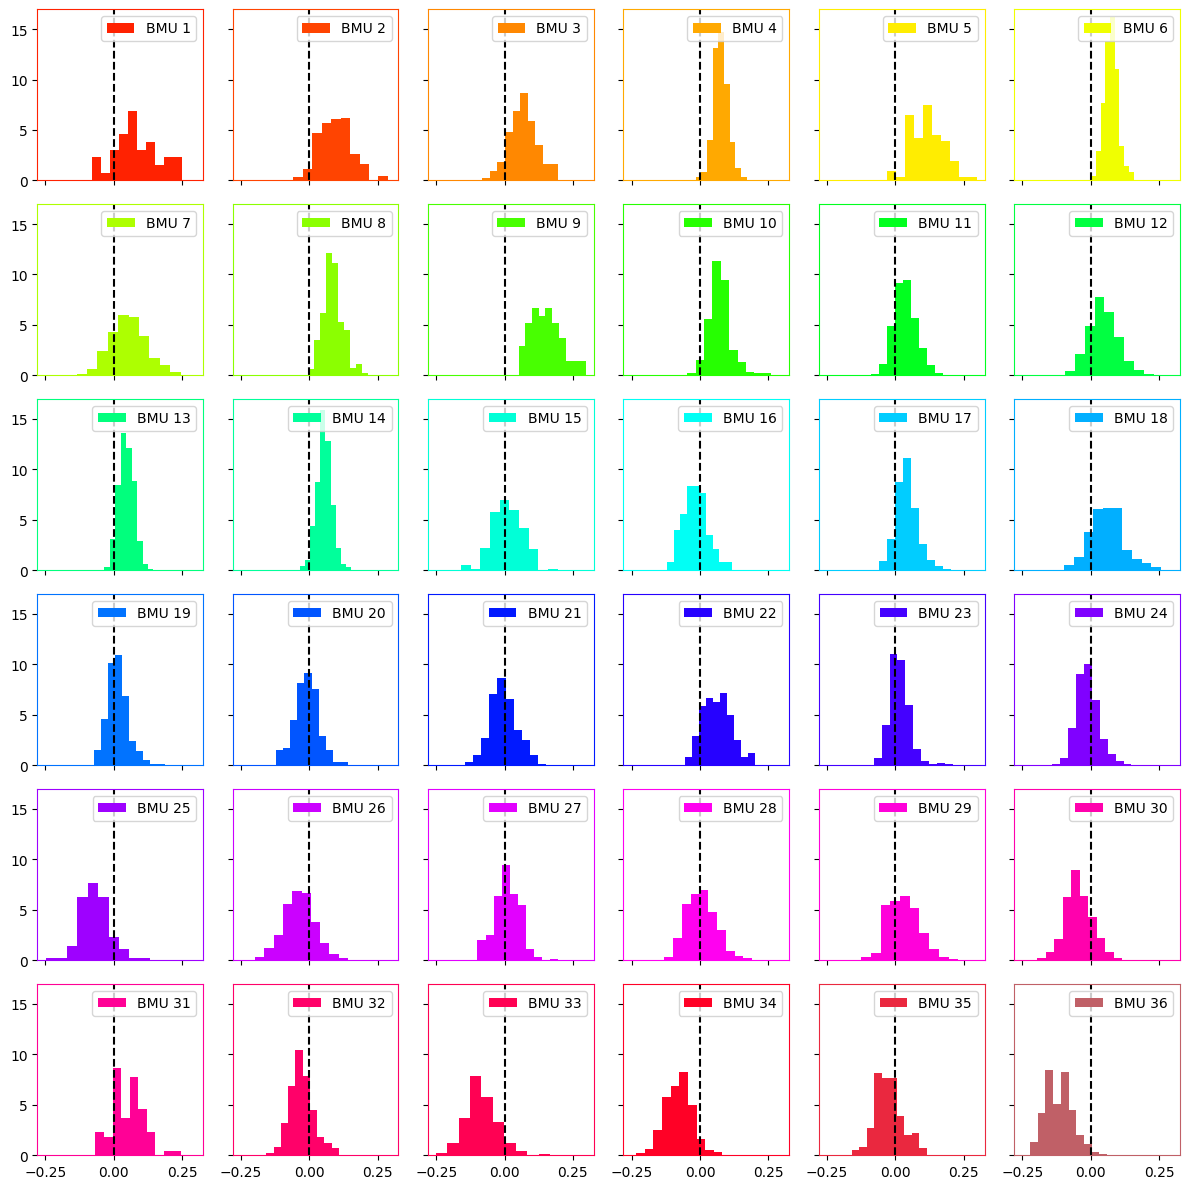

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from bluemath_tk.core.plotting.colors import get_cluster_colors

predictand_variable = "ss"

cluster_colors = get_cluster_colors(xwt.num_clusters)
fig, axes = plt.subplots(6, 6, figsize=(12, 12), sharex=True, sharey=True)
for ax, kma_bmus_index, color in zip(axes.flatten(), range(1, 37), cluster_colors):
    bmus_indexes = np.where(predictand["kma_bmus"].values == kma_bmus_index)[0]
    try:
        predictand[predictand_variable].isel(time=bmus_indexes).squeeze().plot.hist(
            ax=ax,
            color=color,
            label=f"BMU {kma_bmus_index}",
            density=True,
        )
        ax.legend()
        ax.set_title("")
        ax.set_xlabel("")
        if predictand_variable == "ss":
            ax.axvline(x=0, c="k", ls="--")
        for border in ["top", "bottom", "left", "right"]:
            ax.spines[border].set_color(color)
    except:
        pass

plt.tight_layout()